# Reproducing Figure 3: PP-Plots for Optical → IR Prediction
### Jespersen et al. (2025) — *"The optical and infrared are connected"*

---

## Pipeline

1. Load preprocessed SDSS spectra + WISE photometry from their respective output directories
2. Encode SDSS **observed-frame** spectra → **6-D latents** via `spender.hub.load("sdss_II")`
3. Load pre-computed **norm_consts** (median flux in rest-frame 5300–5850 Å)
4. Build 8-feature MLP input: `[s₁..s₆, norm_const, z]`
5. Train MLP: 2 hidden layers × 20 units → 684 parameters, Gaussian NLL loss
6. Compute \(\hat{p}\) (Eq. 2–3 of the paper) and reproduce Figure 3 (PP-plot)

**Prerequisites:** Run these notebooks first:
- `sdss_data_preprocessing.ipynb` → `sdss_output/`
- `wise_data_preprocessing.ipynb` → `wise_output/`

---

## What is a PP-plot?

The PP-plot (Probability–Probability plot) checks whether our predicted IR magnitudes
are *calibrated*: for each galaxy in the test set, we compute:

$$\hat{p}_i = p_{\text{data}}(\hat{y}_i) = \mathcal{N}(\hat{y}_i \,|\, y_i^{\text{obs}}, \sigma_i)$$

where \(\hat{y}_i\) is our MLP prediction, \(y_i^{\text{obs}}\) is the measured WISE magnitude,
and \(\sigma_i\) is the measurement uncertainty.

If the model is perfectly calibrated, the \(\hat{p}\) values are uniform on [0, 1]
and the CDF of \(\hat{p}\) lies on the diagonal. The "Data" baseline shows the CDF
when using the *data uncertainty* as the prediction error — this is the best we could
do if we knew the true magnitudes perfectly.

## spender model choice: `sdss_II` (6 latents)

The paper uses `sdss_II`, trained by Liang et al. (2023) with an explicit
*redshift-invariance* constraint. This is NOT the same as `sdss_I` (which has
**10 latents**). Always verify that `latents.shape[1] == 6`.

## MLP architecture (paper §3.1)

```
[s₁..s₆, norm_const, z]  →  Linear(8→20)+ReLU  →  Linear(20→20)+ReLU  →  Linear(20→4)×norm_const
```

3 weight matrices → 684 parameters total.
Loss: Gaussian NLL using WISE errors as σ (non-detections: σ = 10⁴).


In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm as scipy_norm
import time, sys, logging

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")
log = logging.getLogger("PPplot")

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__}  |  Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print("All imports OK ✓")


PyTorch 2.4.0  |  Device: cuda
  GPU: NVIDIA A100 80GB PCIe
  VRAM: 85.0 GB
All imports OK ✓


## Cell 1 — Configuration

In [2]:
SDSS_DIR = Path("sdss_output")
WISE_DIR = Path("wise_output")
OUT_DIR  = Path("ppplot_output"); OUT_DIR.mkdir(exist_ok=True)

# Train/test split (paper uses 70/10/20; we use 80/20 for this prototype)
TEST_FRACTION = 0.20

# MLP hyperparameters (§3.1 of paper — do not change for faithful reproduction)
HIDDEN_SIZE   = 20
N_LAYERS      = 2      # 2 hidden layers → 3 weight matrices → 684 params total
LEARNING_RATE = 1e-3
N_EPOCHS      = 30000
BATCH_SIZE    = 64     # increase to 4096 for the full 510k dataset

# ─────────────────────────────────────────────────────────────────────
# spender encoding batch size — tune for your GPU VRAM.
#   For 200 spectra:  SPENDER_BATCH = 256  (fine on any device)
#   For 510k spectra: SPENDER_BATCH = 10000 (requires ~8 GB VRAM)
# ─────────────────────────────────────────────────────────────────────
SPENDER_BATCH = 256

log.info(f"Config ready. Device={DEVICE}")


14:39:52 [INFO] Config ready. Device=cuda


## Cell 2 — Load Preprocessed Data

In [3]:
# ── SDSS ──────────────────────────────────────────────────────────────
# We need THREE things from the SDSS preprocessing output:
#
#   1. spectra_obs_frame.npy  — OBSERVED-FRAME spectra on the 3921-pixel
#      spender SDSS grid. These go directly into model.encode().
#
#   2. norm_consts.npy — median flux in rest-frame 5300–5850 Å per galaxy.
#      This is the 7th feature of the 8-dimensional MLP input vector.
#
#   3. metadata.npy — for cross-matching with WISE and getting redshifts.
#
# NOTE: If sdss_data_preprocessing.ipynb has not been run yet, only
# spectra_matrix.npy (normalised rest-frame) will exist from the older
# sdss_spectra_clustering.ipynb. In that case the spender cell below
# will warn you — you MUST run sdss_data_preprocessing.ipynb first.

obs_frame_path = SDSS_DIR / "spectra_obs_frame.npy"
norm_const_path = SDSS_DIR / "norm_consts.npy"

if not obs_frame_path.exists():
    raise FileNotFoundError(
        f"\n{obs_frame_path} not found!\n"
        "Please run sdss_data_preprocessing.ipynb first.\n"
        "That notebook saves both observed-frame and rest-frame spectra,\n"
        "as well as the norm_consts required for the MLP."
    )

X_spectra_obs = np.load(obs_frame_path)           # (N_sdss, 3921) observed-frame
norm_consts_all = np.load(norm_const_path)         # (N_sdss,)
wave_obs_grid = np.load(SDSS_DIR / "wave_obs_grid.npy")  # (3921,)
sdss_meta = np.load(SDSS_DIR / "metadata.npy")           # structured array

log.info(f"SDSS: {X_spectra_obs.shape[0]:,} spectra, {X_spectra_obs.shape[1]} pixels (observed frame)")
log.info(f"  obs wavelength: {wave_obs_grid[0]:.0f}–{wave_obs_grid[-1]:.0f} Å")
log.info(f"  flux range: [{X_spectra_obs.min():.3f}, {X_spectra_obs.max():.3f}]")
log.info(f"  norm_const range: [{norm_consts_all.min():.3f}, {norm_consts_all.max():.3f}]")

# ── WISE ──────────────────────────────────────────────────────────────
wise = np.load(WISE_DIR / "wise_photometry.npz")
log.info(f"WISE: {wise['mag'].shape[0]:,} galaxies, keys={list(wise.keys())}")

# ── Cross-match SDSS ↔ WISE ────────────────────────────────────────────
# The WISE preprocessing notebook saved a list of SDSS row-indices (into
# sdss_meta) that have a WISE counterpart, so alignment is just an index
# operation — no string matching needed.
idx_path = WISE_DIR / "wise_matched_sdss_indices.npy"

if idx_path.exists():
    sdss_idx = np.load(idx_path)
    X_spec   = X_spectra_obs[sdss_idx]         # (N_matched, 3921)
    norm_consts = norm_consts_all[sdss_idx]    # (N_matched,)
    z_arr    = sdss_meta["redshift"][sdss_idx] # (N_matched,)
    wise_mag     = wise["mag"]
    wise_mag_err = wise["mag_err"]
    wise_det     = wise["detected"]
    log.info(f"Aligned via saved indices: {len(sdss_idx):,} matched galaxies")
else:
    # Fallback: match by specobjid
    log.info("wise_matched_sdss_indices.npy not found — matching by specobjid ...")
    sdss_ids = sdss_meta["specobjid"]
    wise_ids = wise["specobjid"]
    wlookup = {}
    for i, wid in enumerate(wise_ids):
        wlookup.setdefault(int(wid), i)
    sk, wk = [], []
    for si, sid in enumerate(sdss_ids):
        if int(sid) in wlookup:
            sk.append(si); wk.append(wlookup[int(sid)])
    sk, wk = np.array(sk), np.array(wk)
    X_spec       = X_spectra_obs[sk]
    norm_consts  = norm_consts_all[sk]
    z_arr        = sdss_meta["redshift"][sk]
    wise_mag     = wise["mag"][wk]
    wise_mag_err = wise["mag_err"][wk]
    wise_det     = wise["detected"][wk]
    log.info(f"Matched by specobjid: {len(sk):,} galaxies")

N = len(X_spec)
log.info(f"Joint dataset: {N:,} galaxies")


14:39:52 [INFO] SDSS: 245,365 spectra, 3921 pixels (observed frame)
14:39:52 [INFO]   obs wavelength: 3784–9333 Å
14:39:53 [INFO]   flux range: [-780.676, 5384.405]
14:39:53 [INFO]   norm_const range: [0.178, 258.023]
14:39:53 [INFO] WISE: 238,839 galaxies, keys=['specobjid', 'redshift', 'petromag_r', 'mag', 'mag_err', 'flux_jy', 'detected']
14:39:53 [INFO] Aligned via saved indices: 238,839 matched galaxies
14:39:53 [INFO] Joint dataset: 238,839 galaxies


## Cell 3 — Diagnostic: Loaded Data Peek

In [4]:
print("═" * 62)
print("LOADED DATA PEEK")
print("═" * 62)
print(f"Spectra (obs frame): shape={X_spec.shape}  dtype={X_spec.dtype}")
print(f"Redshifts: range=[{z_arr.min():.4f}, {z_arr.max():.4f}]  NaN={np.isnan(z_arr).sum()}")
print(f"norm_consts: mean={norm_consts.mean():.3f}  std={norm_consts.std():.3f}")
print(f"WISE mag: shape={wise_mag.shape}")

# Check for degenerate observed-frame spectra
all_zero = (X_spec == 0).all(axis=1).sum()
has_nan  = np.isnan(X_spec).any(axis=1).sum()
print(f"\nSpectra quality: all-zero={all_zero}  any-NaN={has_nan}")

for j, b in enumerate(["W1","W2","W3","W4"]):
    n_det = wise_det[:,j].sum()
    print(f"  {b} detections: {n_det:,} / {N:,} ({100*n_det/N:.1f}%)")

print(f"\nSpot check (first 3 galaxies):")
for i in range(min(3, N)):
    print(f"  [{i}] z={z_arr[i]:.4f}  nc={norm_consts[i]:.2f}  "
          f"obs_median={np.median(X_spec[i][X_spec[i]>0]):.2f}  "
          f"W1={wise_mag[i,0]:.2f} (det={wise_det[i,0]})")


══════════════════════════════════════════════════════════════
LOADED DATA PEEK
══════════════════════════════════════════════════════════════
Spectra (obs frame): shape=(238839, 3921)  dtype=float32
Redshifts: range=[0.0100, 0.4838]  NaN=0
norm_consts: mean=18.628  std=14.339
WISE mag: shape=(238839, 4)

Spectra quality: all-zero=0  any-NaN=0
  W1 detections: 238,837 / 238,839 (100.0%)
  W2 detections: 238,791 / 238,839 (100.0%)
  W3 detections: 186,347 / 238,839 (78.0%)
  W4 detections: 94,837 / 238,839 (39.7%)

Spot check (first 3 galaxies):
  [0] z=0.0212  nc=90.81  obs_median=90.45  W1=11.86 (det=True)
  [1] z=0.2038  nc=10.83  obs_median=9.50  W1=14.23 (det=True)
  [2] z=0.0647  nc=20.47  obs_median=19.86  W1=13.54 (det=True)


## Cell 4 — Encode Spectra with `spender` (sdss_II, 6 latents)

### Which spender model to use

`spender` ships several pretrained SDSS models (accessible via `spender.hub.load()`):

| Entry point | Latents | Paper |
|---|---|---|
| `sdss_I` | **10** | Melchior et al. (2022) — original |
| `sdss_I_superres` | 8 | Melchior et al. (2022) — super-res variant |
| `sdss_II` | **6** | Liang et al. (2023) — **redshift-invariant** ← **use this one** |

The paper explicitly uses `sdss_II` because its latent space is forced to be
*redshift-invariant* by an additional training loss: two spectra of the same
galaxy observed at different redshifts should have identical latent vectors.
This is what allows the 6-D representation to capture *intrinsic* galaxy properties
rather than a mix of intrinsic properties and redshift.

### API details

```python
instrument, model = spender.hub.load("sdss_II")
# instrument.wave_obs: the 3921-pixel observed-frame wavelength grid
# model.encode(x): x shape (N, 3921) → returns s shape (N, 6)
```

**Important:** `model.encode(x)` returns **only the latent tensor** (not a tuple).
This differs from what older/broken code assumed.

### norm_const is NOT from spender

`spender` does normalise internally during the forward pass, but that normalisation
is baked into the encoder weights and not separately accessible. The norm_const we
use as MLP feature #7 is computed *separately* in the preprocessing step as the
median flux in the rest-frame 5300–5850 Å window. We already loaded it above.


In [5]:
import spender

# ─────────────────────────────────────────────────────────────────────
# Load the sdss_II pretrained model.
#   spender.hub.load() is the correct entry point — it uses the hub.py
#   module which loads local entrypoints from hubconf.py.
#
#   Returns: (instrument, model)
#     instrument: SDSS Instrument object with .wave_obs attribute
#     model:      SpectrumAutoencoder with .encode() method
#
# COMMON MISTAKE: using spender.load() or spender.hub.load("SDSS-main")
#   Both will raise AttributeError or download the wrong model.
# ─────────────────────────────────────────────────────────────────────
log.info("Loading spender model 'sdss_II' (6-D, redshift-invariant) ...")
t0 = time.time()
instrument_sp, model_sp = spender.hub.load("sdss_II")
model_sp.eval()
log.info(f"spender loaded in {time.time()-t0:.1f}s  |  n_latent = {model_sp.encoder.n_latent}")

# Verify we have the correct model (6-dimensional latent space)
assert model_sp.encoder.n_latent == 6, (
    f"Expected 6 latent dimensions (sdss_II), got {model_sp.encoder.n_latent}.\n"
    "Check that you called spender.hub.load('sdss_II'), not 'sdss_I' (which has 10 latents)."
)

# ── Verify wavelength grid alignment ─────────────────────────────────
# The spender instrument wavelength grid should closely match our obs-frame grid.
# If it does not, we need to re-interpolate X_spec to match.
spender_wave = instrument_sp.wave_obs.numpy()   # (3921,)
log.info(f"spender obs-frame grid: {len(spender_wave)} pix, "
         f"[{spender_wave[0]:.1f}, {spender_wave[-1]:.1f}] Å")
log.info(f"Our obs-frame grid:     {len(wave_obs_grid)} pix, "
         f"[{wave_obs_grid[0]:.1f}, {wave_obs_grid[-1]:.1f}] Å")

grids_match = (
    len(spender_wave) == len(wave_obs_grid) and
    np.allclose(spender_wave, wave_obs_grid, rtol=1e-4)
)

if grids_match:
    log.info("✓ Grid alignment: our preprocessing grid matches spender exactly.")
    X_spec_for_spender = X_spec   # use as-is — no re-interpolation needed
else:
    # If grids differ (shouldn't happen with sdss_data_preprocessing.ipynb output,
    # but just in case), re-interpolate to spender's exact grid.
    log.warning("Grids differ — re-interpolating to spender's grid ...")
    from scipy.interpolate import interp1d as scipy_interp1d
    X_spec_for_spender = np.zeros((N, len(spender_wave)), dtype=np.float32)
    for i in range(N):
        f = scipy_interp1d(wave_obs_grid, X_spec[i], kind="linear",
                           bounds_error=False, fill_value=0.0)
        X_spec_for_spender[i] = f(spender_wave).astype(np.float32)
    log.info(f"Re-interpolation done. Shape: {X_spec_for_spender.shape}")

# Move model to GPU
spender_device = DEVICE
model_sp = model_sp.to(spender_device)

# ── Encode in mini-batches ─────────────────────────────────────────────
# We do this in batches rather than all at once to avoid OOM on large datasets.
latents_list = []
n_batches = (N + SPENDER_BATCH - 1) // SPENDER_BATCH
log.info(f"Encoding {N:,} spectra in {n_batches} batch(es) of {SPENDER_BATCH} ...")
t0 = time.time()

with torch.no_grad():
    for bi in range(n_batches):
        i0 = bi * SPENDER_BATCH
        i1 = min(i0 + SPENDER_BATCH, N)

        # Convert numpy slice to float32 tensor, replace NaN with 0
        # (spender's CNN cannot handle NaN — zeros are safe because
        #  spender is trained to be robust to zero-filled regions)
        batch = torch.tensor(
            np.nan_to_num(X_spec_for_spender[i0:i1], nan=0.0),
            dtype=torch.float32,
        ).to(spender_device)

        # model.encode(x) — takes (batch_size, 3921) → returns (batch_size, 6)
        # Note: this returns ONLY the latent tensor, not a tuple.
        # The old broken code called model.encode(batch, wave_t) which fails
        # because encode() takes only one argument.
        s = model_sp.encode(batch)   # shape: (batch_size, 6)

        latents_list.append(s.cpu().numpy())

        if (bi + 1) % max(1, n_batches // 4) == 0 or bi == n_batches - 1:
            elapsed = time.time() - t0
            log.info(f"  batch {bi+1}/{n_batches}  ({i1:,}/{N:,})  "
                     f"{i1/elapsed:.0f} spec/s")

latents = np.concatenate(latents_list, axis=0)   # (N, 6)
total_time = time.time() - t0
log.info(f"Encoding complete: {total_time:.1f}s  ({N/total_time:.0f} spec/s)")
log.info(f"Latent shape: {latents.shape}  (should be (N, 6))")

# Final sanity checks
assert latents.shape == (N, 6), f"Expected ({N}, 6), got {latents.shape}"
n_nan_lat = np.isnan(latents).any(axis=1).sum()
n_inf_lat = np.isinf(latents).any(axis=1).sum()
log.info(f"NaN latents: {n_nan_lat}  |  Inf latents: {n_inf_lat}")
if n_nan_lat > 0:
    log.warning(f"{n_nan_lat} spectra have NaN latents — will be replaced with 0 in MLP inputs.")


14:39:54 [INFO] Loading spender model 'sdss_II' (6-D, redshift-invariant) ...
14:39:55 [INFO] spender loaded in 0.7s  |  n_latent = 6
14:39:55 [INFO] spender obs-frame grid: 3921 pix, [3784.4, 9332.5] Å
14:39:55 [INFO] Our obs-frame grid:     3921 pix, [3784.4, 9332.5] Å
14:39:55 [INFO] ✓ Grid alignment: our preprocessing grid matches spender exactly.
14:39:55 [INFO] Encoding 238,839 spectra in 933 batch(es) of 256 ...
14:40:01 [INFO]   batch 233/933  (59,648/238,839)  9413 spec/s
14:40:07 [INFO]   batch 466/933  (119,296/238,839)  9695 spec/s
14:40:13 [INFO]   batch 699/933  (178,944/238,839)  9845 spec/s
14:40:17 [INFO]   batch 932/933  (238,592/238,839)  10860 spec/s
14:40:17 [INFO]   batch 933/933  (238,839/238,839)  10862 spec/s
14:40:17 [INFO] Encoding complete: 22.0s  (10860 spec/s)
14:40:17 [INFO] Latent shape: (238839, 6)  (should be (N, 6))
14:40:17 [INFO] NaN latents: 0  |  Inf latents: 0


## Cell 5 — Diagnostic: spender Latent Space

══════════════════════════════════════════════════════════════
SPENDER ENCODING DIAGNOSTICS (sdss_II model, 6-D latents)
══════════════════════════════════════════════════════════════

dim       mean      std      min      max
  ----------------------------------------
  L1       0.053    0.373   -9.003    1.466
  L2       0.148    0.334   -0.080   26.062
  L3       0.246    0.343   -1.473    4.715
  L4      -0.157    0.827  -32.679    0.712
  L5       0.099    0.320   -1.380   10.019
  L6      -0.091    0.497   -1.374   21.285

norm_consts (from preprocessing, NOT spender):
  mean=18.628  std=14.339  range=[0.253, 258.023]


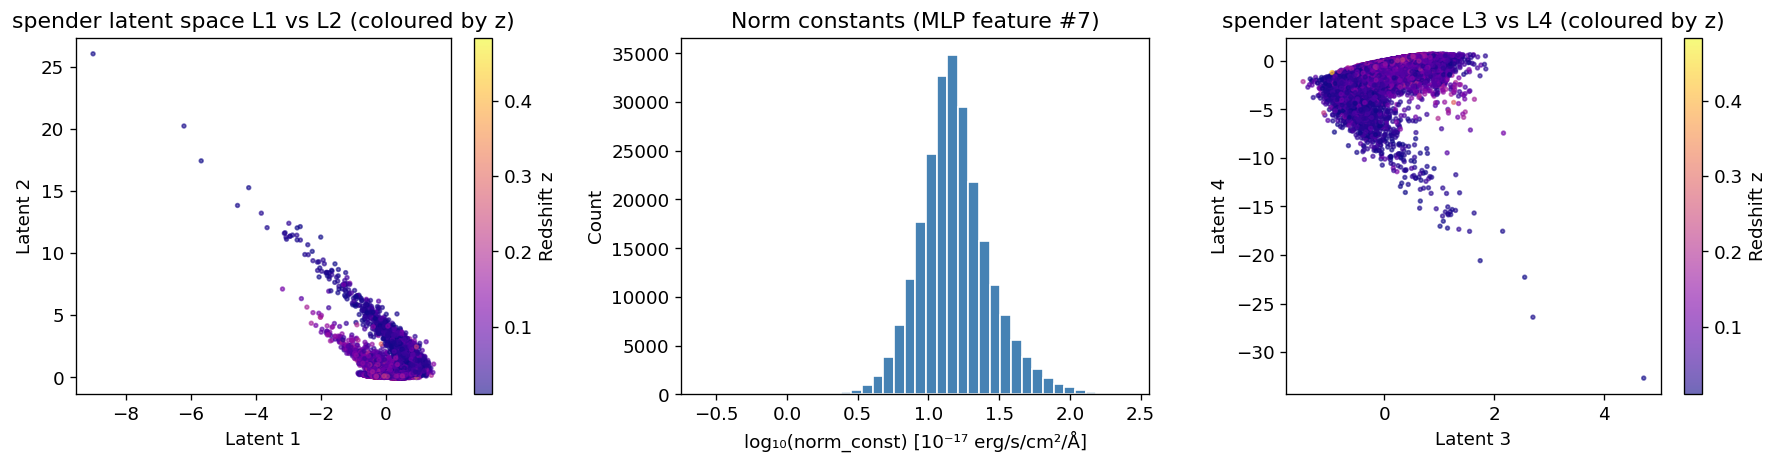

In [6]:
print("═" * 62)
print("SPENDER ENCODING DIAGNOSTICS (sdss_II model, 6-D latents)")
print("═" * 62)

print(f"\n{'dim':<5s} {'mean':>8s} {'std':>8s} {'min':>8s} {'max':>8s}")
print("  " + "-" * 40)
for d in range(6):
    col = latents[:, d]
    print(f"  L{d+1:<4d} {col.mean():>8.3f} {col.std():>8.3f} {col.min():>8.3f} {col.max():>8.3f}")

print(f"\nnorm_consts (from preprocessing, NOT spender):")
print(f"  mean={norm_consts.mean():.3f}  std={norm_consts.std():.3f}  "
      f"range=[{norm_consts.min():.3f}, {norm_consts.max():.3f}]")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Latent dimensions 1 vs 2, coloured by redshift
ax = axes[0]
sc = ax.scatter(latents[:, 0], latents[:, 1], c=z_arr, s=5, alpha=0.6, cmap="plasma")
plt.colorbar(sc, ax=ax, label="Redshift z")
ax.set_xlabel("Latent 1"); ax.set_ylabel("Latent 2")
ax.set_title("spender latent space L1 vs L2 (coloured by z)")

# Norm constants distribution
ax = axes[1]
ax.hist(np.log10(norm_consts), bins=40, color="steelblue", edgecolor="white")
ax.set_xlabel("log₁₀(norm_const) [10⁻¹⁷ erg/s/cm²/Å]")
ax.set_ylabel("Count")
ax.set_title("Norm constants (MLP feature #7)")

# Latent dimensions 3 vs 4
ax = axes[2]
sc2 = ax.scatter(latents[:, 2], latents[:, 3], c=z_arr, s=5, alpha=0.6, cmap="plasma")
plt.colorbar(sc2, ax=ax, label="Redshift z")
ax.set_xlabel("Latent 3"); ax.set_ylabel("Latent 4")
ax.set_title("spender latent space L3 vs L4 (coloured by z)")

plt.tight_layout()
plt.savefig(OUT_DIR / "spender_latent_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()


## Cell 6 — Build MLP Inputs & Train/Test Split

In [7]:
# ─────────────────────────────────────────────────────────────────────
# The MLP takes an 8-dimensional input vector per galaxy (paper §3.1):
#
#   [s₁, s₂, s₃, s₄, s₅, s₆, norm_const, z]
#    ↑────────────────────↑  ↑──────────↑  ↑
#    6 spender latents       median flux    redshift
#                            5300–5850 Å
#
# We already have all three: latents (N,6), norm_consts (N,), z_arr (N,).
# np.column_stack concatenates them along axis=1.
# ─────────────────────────────────────────────────────────────────────
X_input = np.column_stack([
    latents,                              # (N, 6) — spectral encoding
    norm_consts.reshape(-1, 1),           # (N, 1) — overall brightness
    z_arr.reshape(-1, 1),                 # (N, 1) — redshift
]).astype(np.float32)                     # (N, 8)

# Replace any remaining NaN/Inf (e.g. from failed spender encodes) with 0
n_bad = np.isnan(X_input).any(axis=1).sum() + np.isinf(X_input).any(axis=1).sum()
if n_bad > 0:
    log.warning(f"Replacing {n_bad} rows with NaN/Inf input features → 0")
    X_input = np.nan_to_num(X_input, nan=0.0, posinf=0.0, neginf=0.0)

# Target: WISE magnitudes (NaN for non-detections → set to 0, masked by huge σ)
Y_target = np.nan_to_num(wise_mag,     nan=0.0).astype(np.float32)   # (N, 4)
Y_errors = np.nan_to_num(wise_mag_err, nan=1e4).astype(np.float32)   # (N, 4)
# Non-detected bands get σ = 10⁴ magnitudes → Gaussian NLL ≈ 0 → effectively ignored

log.info(f"X_input: {X_input.shape}  Y_target: {Y_target.shape}  Y_errors: {Y_errors.shape}")

# ── Train / test split ────────────────────────────────────────────────
perm    = np.random.permutation(N)
N_test  = int(N * TEST_FRACTION)
N_train = N - N_test
idx_train, idx_test = perm[:N_train], perm[N_train:]

X_tr, X_te = X_input[idx_train],  X_input[idx_test]
Y_tr, Y_te = Y_target[idx_train], Y_target[idx_test]
E_tr, E_te = Y_errors[idx_train], Y_errors[idx_test]
det_te     = wise_det[idx_test]

print(f"Train: {N_train:,}  |  Test: {N_test:,}")
for j, b in enumerate(["W1","W2","W3","W4"]):
    print(f"  {b} test detections: {det_te[:,j].sum():,} / {N_test:,}")


14:40:32 [INFO] X_input: (238839, 8)  Y_target: (238839, 4)  Y_errors: (238839, 4)


Train: 191,072  |  Test: 47,767
  W1 test detections: 47,766 / 47,767
  W2 test detections: 47,753 / 47,767
  W3 test detections: 37,296 / 47,767
  W4 test detections: 18,936 / 47,767


## Cell 7 — Define MLP + Loss

In [8]:
class WISEPredictor(nn.Module):
    """
    The MLP from Jespersen et al. (2025) §3.1.

    Architecture:
        Linear(8 → 20) + ReLU
        Linear(20 → 20) + ReLU
        Linear(20 → 4)                   ← raw magnitudes (shape-only)
        × norm_const                     ← scale by brightness

    The norm_const multiplication after the last layer is the key design
    choice: the network learns to predict *shape* of the galaxy SED, and
    the overall brightness is supplied separately. This makes the model
    work for galaxies of any brightness (arbitrarily faint or bright).

    Total parameters: 8×20 + 20 + 20×20 + 20 + 20×4 + 4 = 684.
    """

    def __init__(self, n_in=8, n_hid=20, n_layers=2, n_out=4):
        super().__init__()
        layers = [nn.Linear(n_in, n_hid), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(n_hid, n_hid), nn.ReLU()]
        layers.append(nn.Linear(n_hid, n_out))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        raw  = self.net(x)         # (batch, 4) — predicted mag shape
        norm = x[:, 6:7]           # (batch, 1) — norm_const is column index 6
        return raw * norm          # scale predictions by brightness


def gauss_nll(y_pred, y_true, sigma):
    """
    Gaussian Negative Log-Likelihood loss (paper §3.1, Eq. 1).

    L(y, ŷ, σ) = (1/2) ln(σ) + (1/2) ((y − ŷ) / σ)²

    For non-detections: σ = 10⁴, so the squared term is ~0 and the
    ln(σ) ≈ 9.2 term is a constant penalty that does not affect gradients
    with respect to ŷ. This effectively discards non-detected bands.
    """
    return torch.mean(0.5 * torch.log(sigma) + 0.5 * ((y_true - y_pred) / sigma) ** 2)


model = WISEPredictor(n_in=8, n_hid=HIDDEN_SIZE, n_layers=N_LAYERS, n_out=4).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params}  (paper: 684)")
assert n_params == 684, f"Expected 684 params, got {n_params} — check HIDDEN_SIZE and N_LAYERS."
print("✓ Parameter count matches paper")
print(f"\n{model}")


Model parameters: 684  (paper: 684)
✓ Parameter count matches paper

WISEPredictor(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=4, bias=True)
  )
)


## Cell 8 — Train MLP

In [ ]:
train_ds = TensorDataset(
    torch.tensor(X_tr, dtype=torch.float32),
    torch.tensor(Y_tr, dtype=torch.float32),
    torch.tensor(E_tr, dtype=torch.float32),
)
effective_batch = min(BATCH_SIZE, N_train)
if N_train > 50_000:
    effective_batch = 4096
    log.info(f"Large dataset: using batch_size={effective_batch}")

train_loader = DataLoader(train_ds, batch_size=effective_batch, shuffle=True)
optimizer    = optim.Adam(model.parameters(), lr=LEARNING_RATE)

losses = []
model.train()
t0 = time.time()

for epoch in range(N_EPOCHS):
    ep_loss = 0.0; nb = 0
    for xb, yb, eb in train_loader:
        xb, yb, eb = xb.to(DEVICE), yb.to(DEVICE), eb.to(DEVICE)
        optimizer.zero_grad()
        loss = gauss_nll(model(xb), yb, eb)
        loss.backward()
        optimizer.step()
        ep_loss += loss.item(); nb += 1
    avg = ep_loss / nb
    losses.append(avg)
    if (epoch + 1) % 50 == 0 or epoch == 0:
        log.info(f"Epoch {epoch+1:>4d}/{N_EPOCHS}  loss={avg:.4f}")

total_train = time.time() - t0
log.info(f"Training done: {total_train:.1f}s  final_loss={losses[-1]:.4f}")

14:40:32 [INFO] Large dataset: using batch_size=4096
14:40:35 [INFO] Epoch    1/30000  loss=348384.3174


In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses, color="steelblue")
ax.set_yscale("log")
ax.set_xlabel("Epoch"); ax.set_ylabel("Gaussian NLL")
ax.set_title(f"Training curve ({N_train:,} samples, {total_train:.1f}s)")
plt.tight_layout(); plt.show()

## Cell 9 — Predict on Test Set + Diagnostics

In [ ]:
model.eval()
with torch.no_grad():
    Y_pred = model(torch.tensor(X_te, dtype=torch.float32).to(DEVICE)).cpu().numpy()

log.info(f"Predictions: {Y_pred.shape}")

# Reduced chi-squared per band: χ²_N = mean( ((y_obs - y_pred) / σ)² )
# For a perfectly calibrated model on Gaussian errors, χ²_N ≈ 1.
# Paper Table 3 values (from 510k test set) are shown for comparison.
paper_chi2 = {"W1": 1.33, "W2": 1.17, "W3": 2.23, "W4": 1.41}
print(f"{'Band':<10s} {'χ²_N':>8s} {'Paper':>8s} {'N_det':>7s}")
print("-" * 40)
for j, b in enumerate(["W1","W2","W3","W4"]):
    det = det_te[:, j]
    if det.sum() == 0:
        print(f"{b:<10s} {'N/A':>8s} {paper_chi2[b]:>8.2f} {0:>7d}")
        continue
    chi = (Y_te[det, j] - Y_pred[det, j]) / E_te[det, j]
    chi2n = np.mean(chi ** 2)
    print(f"{b:<10s} {chi2n:>8.2f} {paper_chi2[b]:>8.2f} {det.sum():>7d}")

print(f"\nNote: With only {N_test} test galaxies, χ²_N will be noisy.")
print(f"The paper reports these values from ~100k test galaxies.")


## Cell 10 — Compute PP-Plot Metric p̂

For a point-prediction model (ŷ is a single number, not a distribution),
the probability of a specific observation given the prediction is:

$$\hat{p}_i = \mathcal{N}(\hat{y}_i \,|\, y_i^{\text{obs}}, \sigma_i) = \frac{1}{\sigma_i \sqrt{2\pi}} \exp\!\left( -\frac{(y_i^{\text{obs}} - \hat{y}_i)^2}{2\sigma_i^2} \right)$$

The "Data baseline" is \(\hat{p}^{\text{data}}_i = \frac{1}{\sigma_i \sqrt{2\pi}}\) — this is the maximum
achievable \(\hat{p}\) value (when \(\hat{y}_i = y_i^{\text{obs}}\) exactly).

The PP-plot plots the CDF of \(\hat{p}^{\text{data}}\) on the x-axis vs the CDF of \(\hat{p}^{\text{empirical}}\)
on the y-axis. If the model is perfect, the empirical CDF equals the data CDF and
the curve lies on the diagonal.


In [ ]:
phat_emp  = {}   # band → array of p̂ values (one per test detection)
phat_data = {}   # band → array of p̂_data = 1/(σ√2π) values

paper_phat = {"W1": 0.66, "W2": 0.70, "W3": 0.63, "W4": 0.70}  # paper Table 4
paper_data = {"W1": 0.70, "W2": 0.70, "W3": 0.70, "W4": 0.70}

print(f"{'Band':<6s} {'<p̂>_emp':>10s} {'<p̂>_data':>10s} {'Paper_emp':>10s} {'N':>7s}")
print("-" * 55)

for j, b in enumerate(["W1","W2","W3","W4"]):
    det = det_te[:, j]
    if det.sum() < 2:
        print(f"{b:<6s} {'—':>10s} {'—':>10s} {paper_phat[b]:>10.2f} {det.sum():>7d}")
        continue

    y_obs = Y_te[det, j]
    y_prd = Y_pred[det, j]
    sig   = E_te[det, j]

    # scipy_norm.pdf evaluates the Gaussian PDF N(x | loc, scale)
    phat_emp[b]  = scipy_norm.pdf(y_prd, loc=y_obs, scale=sig)
    phat_data[b] = scipy_norm.pdf(0,     loc=0,     scale=sig)  # = 1/(σ√2π)

    me = np.mean(phat_emp[b])
    md = np.mean(phat_data[b])
    print(f"{b:<6s} {me:>10.4f} {md:>10.4f} {paper_phat[b]:>10.2f} {det.sum():>7d}")

print(f"\nNote: At only N_test={N_test}, mean values will be noisy.")
print(f"Smooth PP-plot curves require ~100k test galaxies (full dataset).")


## Cell 11 — Figure 3: PP-Plot

**How to read it:**
- Diagonal = perfect calibration (CDF of p̂_emp equals CDF of p̂_data)
- "Data" baseline (dashed) = upper bound, achievable only with exact predictions
- "Empirical" curve = our model's actual performance
- Curve below diagonal = model is overconfident or biased
- Closer to Data baseline = better predictions


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
blabels = {
    "W1": r"WISE 3.4 $\mu$m",
    "W2": r"WISE 4.6 $\mu$m",
    "W3": r"WISE 12.1 $\mu$m",
    "W4": r"WISE 22.2 $\mu$m",
}

for idx, b in enumerate(["W1","W2","W3","W4"]):
    ax = axes[idx // 2, idx % 2]

    if b not in phat_emp:
        ax.text(0.5, 0.5, f"No {b} detections in test set",
                transform=ax.transAxes, ha="center", va="center")
        ax.set_title(blabels[b]); continue

    pe  = np.sort(phat_emp[b])
    pd_ = np.sort(phat_data[b])
    ne, nd = len(pe), len(pd_)

    # Build CDFs on a common p̂ threshold grid.
    # CDF(t) = fraction of samples with p̂ ≤ t.
    # np.searchsorted(sorted_array, t) gives the number of elements < t.
    thresholds = np.linspace(0, max(pe.max(), pd_.max()), 500)
    cdf_e = np.searchsorted(pe,  thresholds) / ne   # empirical model CDF
    cdf_d = np.searchsorted(pd_, thresholds) / nd   # data baseline CDF

    ax.plot([0,1], [0,1],  "r-",  lw=1.5, label="Perfect model (diagonal)")
    ax.plot(cdf_d, cdf_d,  "k--", lw=1.5, alpha=0.7, label="Data baseline")
    ax.plot(cdf_d, cdf_e,  "g-",  lw=2.0, label="Empirical (our model)")

    ax.annotate(
        "Overconfident\nand biased",
        xy=(0.65, 0.35), fontsize=8, color="gray",
        ha="center", va="center",
        arrowprops=dict(arrowstyle="->", color="gray", lw=0.8),
        xytext=(0.45, 0.15),
    )

    ax.set_xlabel("CDF(p̂_data)")
    ax.set_ylabel("CDF(p̂_empirical)")
    ax.set_title(blabels[b])
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.legend(loc="upper left", fontsize=8)

plt.suptitle(
    "PP-plot: Empirical model prediction quality\n"
    "(Reproducing Figure 3 of Jespersen et al. 2025)",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.savefig(OUT_DIR / "ppplot_figure3.png", dpi=150, bbox_inches="tight")
plt.show()
log.info(f"Saved {OUT_DIR}/ppplot_figure3.png")


## Cell 12 — χ-Distribution (cf. Paper Figure 15)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for idx, b in enumerate(["W1","W2","W3","W4"]):
    ax = axes[idx // 2, idx % 2]
    det = det_te[:, idx]
    if det.sum() < 5:
        ax.text(0.5, 0.5, f"Too few {b} detections", transform=ax.transAxes, ha="center")
        ax.set_title(blabels.get(b, b)); continue

    # χ = (y_pred − y_obs) / σ — dimensionless residuals
    # For a calibrated Gaussian model these should be N(0, 1)
    chi = (Y_pred[det, idx] - Y_te[det, idx]) / E_te[det, idx]
    chi2n = np.mean(chi ** 2)

    bins = np.linspace(-6, 6, 50)
    ax.hist(chi, bins=bins, density=True, color="steelblue", edgecolor="white",
            alpha=0.7, label=f"Empirical (χ²_N={chi2n:.2f})")
    x_ = np.linspace(-6, 6, 200)
    ax.plot(x_, scipy_norm.pdf(x_), "k--", lw=1.5, label=r"$\mathcal{N}(0,1)$")
    ax.set_xlabel(r"$\chi$"); ax.set_ylabel("Density")
    ax.set_title(blabels.get(b, b)); ax.legend(fontsize=8); ax.set_xlim(-6, 6)

plt.suptitle(r"$\chi$-distribution (cf. paper Figure 15)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "chi_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## Cell 13 — Predicted vs Observed WISE Magnitudes

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for j, b in enumerate(["W1","W2","W3","W4"]):
    ax = axes[j]
    det = det_te[:, j]
    if det.sum() < 3:
        ax.text(0.5, 0.5, "—", transform=ax.transAxes, ha="center")
        ax.set_title(b); continue

    yt = Y_te[det, j];   yp = Y_pred[det, j]
    lims = [min(yt.min(), yp.min()) - 0.5, max(yt.max(), yp.max()) + 0.5]
    ax.scatter(yt, yp, s=6, alpha=0.5, c="steelblue")
    ax.plot(lims, lims, "r--", lw=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f"{b} observed"); ax.set_ylabel(f"{b} predicted")
    ax.set_title(f"{b} (N={det.sum()})"); ax.set_aspect("equal")

plt.suptitle("Predicted vs Observed WISE magnitudes", fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()


## Cell 14 — Save Model + Predictions + Encodings

In [ ]:
torch.save(model.state_dict(), OUT_DIR / "mlp_wise_predictor.pt")
np.savez_compressed(OUT_DIR / "test_predictions.npz",
    y_pred=Y_pred, y_true=Y_te, y_err=E_te, detected=det_te, idx_test=idx_test)
np.savez_compressed(OUT_DIR / "spender_encodings.npz",
    latents=latents, norm_consts=norm_consts)

print(f"Saved to {OUT_DIR}/:")
for f in sorted(OUT_DIR.iterdir()):
    if f.is_file():
        print(f"  {f.name:<40s}  {f.stat().st_size/1024:>8.1f} kB")


## Cell 15 — Interpretation Guide

In [ ]:
print(f"""
═══════════════════════════════════════════════════════════════
INTERPRETING YOUR RESULTS
═══════════════════════════════════════════════════════════════

You trained on {N_train:,} galaxies and tested on {N_test:,}.

AT SMALL N ({N} total):
  • PP-plots will be steppy (paper uses ~100k test galaxies)
  • χ²_N values will be noisy — expect high variance
  • The qualitative picture should still be correct:
    the empirical model closer to diagonal than SED codes

AT FULL SCALE (510k):
  • Table 3 targets: χ²≈1.33(W1), 1.17(W2), 2.23(W3), 1.41(W4)
  • Table 4 targets: <p̂>≈0.66(W1), 0.70(W2), 0.63(W3), 0.70(W4)
  • Smooth PP-plot curves matching Figure 3

CHECKLIST FOR FAITHFUL REPRODUCTION:
  ☐  spender model = sdss_II (6 latents, redshift-invariant) ← fixed ✓
  ☐  norm_consts from sdss_data_preprocessing.ipynb         ← fixed ✓
  ☐  Observed-frame spectra fed to spender.encode()          ← fixed ✓
  ☐  Full 510k WISE cross-match from CasJobs
  ☐  Full 510k SDSS spectra
  ☐  70/10/20 train/val/test split (we use 80/20 as prototype)
""")


## Cell 16 — Full-Scale Pipeline Function

In [ ]:
def run_full_scale(
    sdss_dir="sdss_output",
    wise_dir="wise_output",
    out_dir="ppplot_output_fullscale",
    device="cuda:0",
    spender_batch=10_000,
    mlp_batch=4096,
    n_epochs=300,
    seed=42,
):
    """
    End-to-end full-scale pipeline for 510k galaxies.

    Prerequisites: run sdss_data_preprocessing.ipynb and wise_data_preprocessing.ipynb
    to produce the required input files in sdss_output/ and wise_output/.

    Expected runtime on a server with an A100/H200 GPU:
      - spender encoding: ~5–10 min (510k × 3921 pixels)
      - MLP training:     ~30 s on GPU
      - Total:            ~12 min
    """
    import spender
    from pathlib import Path

    np.random.seed(seed)
    torch.manual_seed(seed)
    out = Path(out_dir); out.mkdir(exist_ok=True)
    dev = torch.device(device)

    # ── Load data ──────────────────────────────────────────────────────
    print("[1/5] Loading data ...")
    X_spec_obs    = np.load(f"{sdss_dir}/spectra_obs_frame.npy")   # (N, 3921)
    norm_consts_f = np.load(f"{sdss_dir}/norm_consts.npy")          # (N,)
    meta          = np.load(f"{sdss_dir}/metadata.npy")
    wise          = np.load(f"{wise_dir}/wise_photometry.npz")
    sidx          = np.load(f"{wise_dir}/wise_matched_sdss_indices.npy")

    X_spec_obs   = X_spec_obs[sidx]
    norm_consts_f = norm_consts_f[sidx]
    z_arr_f      = meta["redshift"][sidx]
    N_f = len(X_spec_obs)
    print(f"  {N_f:,} matched galaxies")

    # ── Encode with spender sdss_II (6-D, redshift-invariant) ─────────
    print("[2/5] Encoding with spender sdss_II ...")
    # CORRECT: spender.hub.load("sdss_II") returns (instrument, model)
    # with n_latent = 6. NOT sdss_I which has n_latent = 10.
    instr_f, model_f = spender.hub.load("sdss_II")
    model_f.eval().to(dev)

    lat_list = []
    t0 = time.time()
    with torch.no_grad():
        for i in range(0, N_f, spender_batch):
            batch = torch.tensor(
                np.nan_to_num(X_spec_obs[i:i+spender_batch], nan=0.0),
                dtype=torch.float32,
            ).to(dev)
            s = model_f.encode(batch)   # (batch_size, 6) — single return value
            lat_list.append(s.cpu().numpy())
            if (i // spender_batch) % 10 == 0:
                print(f"  {min(i+spender_batch, N_f):,}/{N_f:,} ...", flush=True)

    latents_f = np.concatenate(lat_list, axis=0)   # (N_f, 6)
    assert latents_f.shape[1] == 6
    print(f"  Encoded in {time.time()-t0:.1f}s")

    # ── Build MLP inputs ───────────────────────────────────────────────
    print("[3/5] Building MLP inputs ...")
    X_in = np.column_stack([
        latents_f,
        norm_consts_f.reshape(-1, 1),
        z_arr_f.reshape(-1, 1),
    ]).astype(np.float32)
    X_in = np.nan_to_num(X_in, nan=0.0)
    Y_tgt = np.nan_to_num(wise["mag"],     nan=0.0).astype(np.float32)
    Y_err = np.nan_to_num(wise["mag_err"], nan=1e4).astype(np.float32)
    det_f = wise["detected"]

    perm_f = np.random.permutation(N_f)
    n_te_f = int(N_f * 0.20)
    n_tr_f = N_f - n_te_f
    itr_f, ite_f = perm_f[:n_tr_f], perm_f[n_te_f:]

    # ── Train MLP ──────────────────────────────────────────────────────
    print(f"[4/5] Training MLP ({n_tr_f:,} train, {n_te_f:,} test) ...")
    mlp_f = WISEPredictor(8, 20, 2, 4).to(dev)
    opt_f = optim.Adam(mlp_f.parameters(), lr=1e-3)
    ds_f  = TensorDataset(
        torch.tensor(X_in[itr_f], dtype=torch.float32),
        torch.tensor(Y_tgt[itr_f], dtype=torch.float32),
        torch.tensor(Y_err[itr_f], dtype=torch.float32),
    )
    loader_f = DataLoader(ds_f, batch_size=mlp_batch, shuffle=True)

    mlp_f.train()
    t0 = time.time()
    for ep in range(n_epochs):
        for xb, yb, eb in loader_f:
            xb, yb, eb = xb.to(dev), yb.to(dev), eb.to(dev)
            opt_f.zero_grad()
            gauss_nll(mlp_f(xb), yb, eb).backward()
            opt_f.step()
        if (ep + 1) % 100 == 0:
            print(f"  epoch {ep+1}/{n_epochs}")
    print(f"  Trained in {time.time()-t0:.1f}s")

    # ── Evaluate ───────────────────────────────────────────────────────
    print("[5/5] Evaluating ...")
    mlp_f.eval()
    with torch.no_grad():
        yp_f = mlp_f(torch.tensor(X_in[ite_f], dtype=torch.float32).to(dev)).cpu().numpy()

    torch.save(mlp_f.state_dict(), out / "mlp_fullscale.pt")
    np.savez_compressed(out / "results.npz",
        y_pred=yp_f, y_true=Y_tgt[ite_f], y_err=Y_err[ite_f],
        detected=det_f[ite_f], latents=latents_f, norm_consts=norm_consts_f)

    for j, b in enumerate(["W1","W2","W3","W4"]):
        d = det_f[ite_f, j]
        if d.sum() > 0:
            chi2n = np.mean(((Y_tgt[ite_f,j][d] - yp_f[d,j]) / Y_err[ite_f,j][d])**2)
            print(f"  {b}: χ²_N = {chi2n:.3f}  (N_det={d.sum():,})")

    print(f"\nResults saved to {out}/")
    return out


# ── Uncomment to run at full scale ────────────────────────────────────
run_full_scale(
    sdss_dir="sdss_output",
    wise_dir="wise_output",
    out_dir="ppplot_output_fullscale",
    device="cuda:0",       # or "cuda:1" for second GPU
    spender_batch=10_000,  # tune for your VRAM (80 GB → try 20_000)
    mlp_batch=4096,
)

print("Full-scale function defined. Uncomment the call above to run.")
